# Manual Data Loader and Visualizer
Load and process manual driving data with time normalization and acceleration calculation from velocity.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import glob
import matplotlib.pyplot as plt

## Define ManualDataLoader Class

In [2]:
class ManualDataLoader:
    def __init__(self, data_folder: str):
        """
        Initialize loader with folder containing manual CSV files.

        Args:
            data_folder: Path to folder containing manual CSV files
        """
        self.data_folder = Path(data_folder)
        all_csv_files = sorted(self.data_folder.glob("*.csv"))
        self.csv_files = [f for f in all_csv_files if not f.stem.endswith("_normalized")]
        self.data = {}

    def convert_time_to_seconds(self, time_str: str) -> float:
        """Convert time string MM:SS.S to seconds."""
        try:
            parts = time_str.strip().split(':')
            minutes = int(parts[0])
            seconds = float(parts[1])
            return minutes * 60 + seconds
        except (ValueError, IndexError):
            return np.nan

    def clean_velocity_series(self, v, min_val=0.0, max_val=20.0, max_jump=0.5, interp_limit=5, rolling_window=5):
        """
        Clean velocity data by removing outliers, clipping, and smoothing.
        
        Args:
            v: velocity series
            min_val: minimum valid velocity
            max_val: maximum valid velocity
            max_jump: maximum allowed change per sample
            interp_limit: maximum gap to interpolate
            rolling_window: window size for median filter
        """
        v = pd.to_numeric(v, errors="coerce")
        v.loc[v > 100] = 0.0  # Remove garbage spikes
        v = v.clip(lower=min_val, upper=max_val)
        dv = v.diff().abs()
        v.loc[dv > max_jump] = np.nan  # Remove large jumps
        v = v.interpolate(method="linear", limit=interp_limit, limit_direction="both")  # Fill gaps
        v = v.rolling(window=rolling_window, center=True, min_periods=1).median()  # Smooth
        return v

    def compute_acceleration_from_velocity(self, df, time_col, velocity_col):
        """
        Calculate acceleration from velocity using 1-second intervals.
        Bins velocity into 1-second intervals, averages within each bin,
        then calculates acceleration as change in average velocity.
        """
        temp = df[[time_col, velocity_col]].copy()
        temp[time_col] = pd.to_numeric(temp[time_col], errors="coerce")
        temp[velocity_col] = pd.to_numeric(temp[velocity_col], errors="coerce")

        temp = temp.dropna(subset=[time_col, velocity_col]).sort_values(time_col)

        if temp.empty:
            return pd.Series(np.nan, index=df.index)

        # Bin into 1-second intervals
        temp["time_bin"] = np.floor(temp[time_col]).astype(int)

        # Average velocity within each 1-second interval
        vel_per_sec = temp.groupby("time_bin")[velocity_col].mean()

        # Calculate acceleration as change in velocity per second
        time_sec = vel_per_sec.index.to_series().astype(float)
        dt = time_sec.diff()

        acc_per_sec = vel_per_sec.diff() / dt
        acc_per_sec = acc_per_sec.fillna(0)

        # Map acceleration back to original time points
        time_bin = np.floor(pd.to_numeric(df[time_col], errors="coerce")).astype("Int64")

        return time_bin.map(acc_per_sec)

    def load_and_normalize(self) -> dict:
        """
        Load all CSV files and normalize time data.
        Calculate acceleration from both raw and cleaned velocity.

        Returns:
            Dictionary with DataFrames for each file containing:
            - time_seconds: Time in seconds (normalized from 0)
            - velocity_kmph: Original vehicle speed in km/h
            - velocity_kmph_clean: Cleaned vehicle speed in km/h
            - velocity_ms: Cleaned velocity in m/s
            - velocity_ms_raw: Raw velocity in m/s
            - acceleration_raw: Calculated acceleration from raw velocity (m/s²)
            - acceleration_clean: Calculated acceleration from cleaned velocity (m/s²)
        """
        all_data = {}

        for csv_file in self.csv_files:
            filename = csv_file.stem
            print(f"Loading {filename}...")

            # Read CSV
            df = pd.read_csv(csv_file)

            # Extract relevant columns
            if 'Time' in df.columns and 'Vehicle | Vehicle Speed' in df.columns:
                # Convert time to seconds
                df['time_seconds'] = df['Time'].apply(self.convert_time_to_seconds)

                # Extract original velocity in km/h
                df['velocity_kmph'] = df['Vehicle | Vehicle Speed'].astype(float)

                # Convert raw velocity to m/s
                df['velocity_ms_raw'] = df['velocity_kmph'] * (5/18)

                # Calculate acceleration from raw velocity in m/s
                df['acceleration_raw'] = self.compute_acceleration_from_velocity(df, 'time_seconds', 'velocity_ms_raw')

                # Clean velocity data
                df['velocity_kmph_clean'] = self.clean_velocity_series(
                    df['velocity_kmph'].copy(),
                    min_val=0.0,
                    max_val=20.0,
                    max_jump=0.5,
                    rolling_window=5
                )

                # Convert cleaned velocity to m/s
                df['velocity_ms'] = df['velocity_kmph_clean'] * (5/18)

                # Calculate acceleration from cleaned velocity in m/s
                df['acceleration_clean'] = self.compute_acceleration_from_velocity(df, 'time_seconds', 'velocity_ms')

                # Normalize time to start from 0
                df['time_seconds'] = df['time_seconds'] - df['time_seconds'].min()

                # Keep only relevant columns
                processed_df = df[['time_seconds', 'velocity_kmph', 'velocity_kmph_clean', 
                                   'velocity_ms_raw', 'velocity_ms', 'acceleration_raw', 'acceleration_clean']].copy()
                all_data[filename] = processed_df

                print(f"  - Loaded {len(processed_df)} rows")
                print(f"  - Time range: {processed_df['time_seconds'].min():.2f}s - {processed_df['time_seconds'].max():.2f}s")
                print(f"  - Velocity range (raw): {processed_df['velocity_kmph'].min():.2f} - {processed_df['velocity_kmph'].max():.2f} km/h")
                print(f"  - Velocity range (clean): {processed_df['velocity_kmph_clean'].min():.2f} - {processed_df['velocity_kmph_clean'].max():.2f} km/h")
                print(f"  - Acceleration (raw): {processed_df['acceleration_raw'].min():.3f} - {processed_df['acceleration_raw'].max():.3f} m/s²")
                print(f"  - Acceleration (clean): {processed_df['acceleration_clean'].min():.3f} - {processed_df['acceleration_clean'].max():.3f} m/s²")
                print()
            else:
                print(f"  - Missing required columns in {filename}")

        self.data = all_data
        return all_data

    def get_combined_data(self) -> pd.DataFrame:
        """
        Combine all datasets with a file identifier.

        Returns:
            Combined DataFrame with 'filename' column
        """
        combined_list = []
        for filename, df in self.data.items():
            df_copy = df.copy()
            df_copy['filename'] = filename
            combined_list.append(df_copy)

        return pd.concat(combined_list, ignore_index=True)

    def save_normalized_data(self):
        """Save normalized data to same folder as original CSV files."""
        for filename, df in self.data.items():
            output_file = self.data_folder / f"{filename}_normalized.csv"
            try:
                df.to_csv(output_file, index=False)
                print(f"Saved: {output_file}")
            except PermissionError:
                print(f"Warning: Could not save {output_file} (file may be in use)")

## Load and Process Data

In [3]:
# Initialize loader with current folder
manual_data_folder = "."
loader = ManualDataLoader(manual_data_folder)

# Load and normalize data
normalized_data = loader.load_and_normalize()

Loading Energy_Consumption_50s_Window...
  - Missing required columns in Energy_Consumption_50s_Window
Loading Manual_10kmph...
  - Loaded 316 rows
  - Time range: 0.00s - 61.60s
  - Velocity range (raw): 0.00 - 10.90 km/h
  - Velocity range (clean): 0.00 - 10.90 km/h
  - Acceleration (raw): -0.735 - 0.903 m/s²
  - Acceleration (clean): -0.708 - 0.781 m/s²

Loading Manual_5kmph...
  - Loaded 380 rows
  - Time range: 0.00s - 64.30s
  - Velocity range (raw): 0.00 - 5.20 km/h
  - Velocity range (clean): 0.00 - 5.10 km/h
  - Acceleration (raw): -0.420 - 0.414 m/s²
  - Acceleration (clean): -0.420 - 0.421 m/s²

Loading Manual_variable...
  - Loaded 2081 rows
  - Time range: 0.00s - 456.60s
  - Velocity range (raw): -0.20 - 14.70 km/h
  - Velocity range (clean): 0.00 - 14.60 km/h
  - Acceleration (raw): -0.589 - 0.761 m/s²
  - Acceleration (clean): -0.615 - 0.732 m/s²

Loading Manual_Variable_2...
  - Loaded 549 rows
  - Time range: 0.00s - 60.90s
  - Velocity range (raw): 0.00 - 11.40 km/h


## Data Summary

In [4]:
print("="*60)
print("SUMMARY")
print("="*60)
for filename, df in normalized_data.items():
    print(f"\n{filename}:")
    print(df.head(10))

SUMMARY

Manual_10kmph:
   time_seconds  velocity_kmph  velocity_kmph_clean  velocity_ms_raw  \
0           0.0            0.0                  0.0              0.0   
1           0.1            0.0                  0.0              0.0   
2           0.2            0.0                  0.0              0.0   
3           0.3            0.0                  0.0              0.0   
4           0.4            0.0                  0.0              0.0   
5           0.5            0.0                  0.0              0.0   
6           0.7            0.0                  0.0              0.0   
7           0.9            0.0                  0.0              0.0   
8           0.9            0.0                  0.0              0.0   
9           1.1            0.0                  0.0              0.0   

   velocity_ms  acceleration_raw  acceleration_clean  
0          0.0               0.0                 0.0  
1          0.0               0.0                 0.0  
2          0.0    

## Combined Dataset

In [5]:
# Get combined dataset
combined = loader.get_combined_data()
print("Combined dataset shape:", combined.shape)
print(combined.head())

Combined dataset shape: (3326, 8)
   time_seconds  velocity_kmph  velocity_kmph_clean  velocity_ms_raw  \
0           0.0            0.0                  0.0              0.0   
1           0.1            0.0                  0.0              0.0   
2           0.2            0.0                  0.0              0.0   
3           0.3            0.0                  0.0              0.0   
4           0.4            0.0                  0.0              0.0   

   velocity_ms  acceleration_raw  acceleration_clean       filename  
0          0.0               0.0                 0.0  Manual_10kmph  
1          0.0               0.0                 0.0  Manual_10kmph  
2          0.0               0.0                 0.0  Manual_10kmph  
3          0.0               0.0                 0.0  Manual_10kmph  
4          0.0               0.0                 0.0  Manual_10kmph  


## Save Normalized Data

In [6]:
# Save normalized data to same folder
loader.save_normalized_data()

Saved: Manual_10kmph_normalized.csv
Saved: Manual_5kmph_normalized.csv
Saved: Manual_variable_normalized.csv
Saved: Manual_Variable_2_normalized.csv


## Visualization
Add your visualization code below this cell

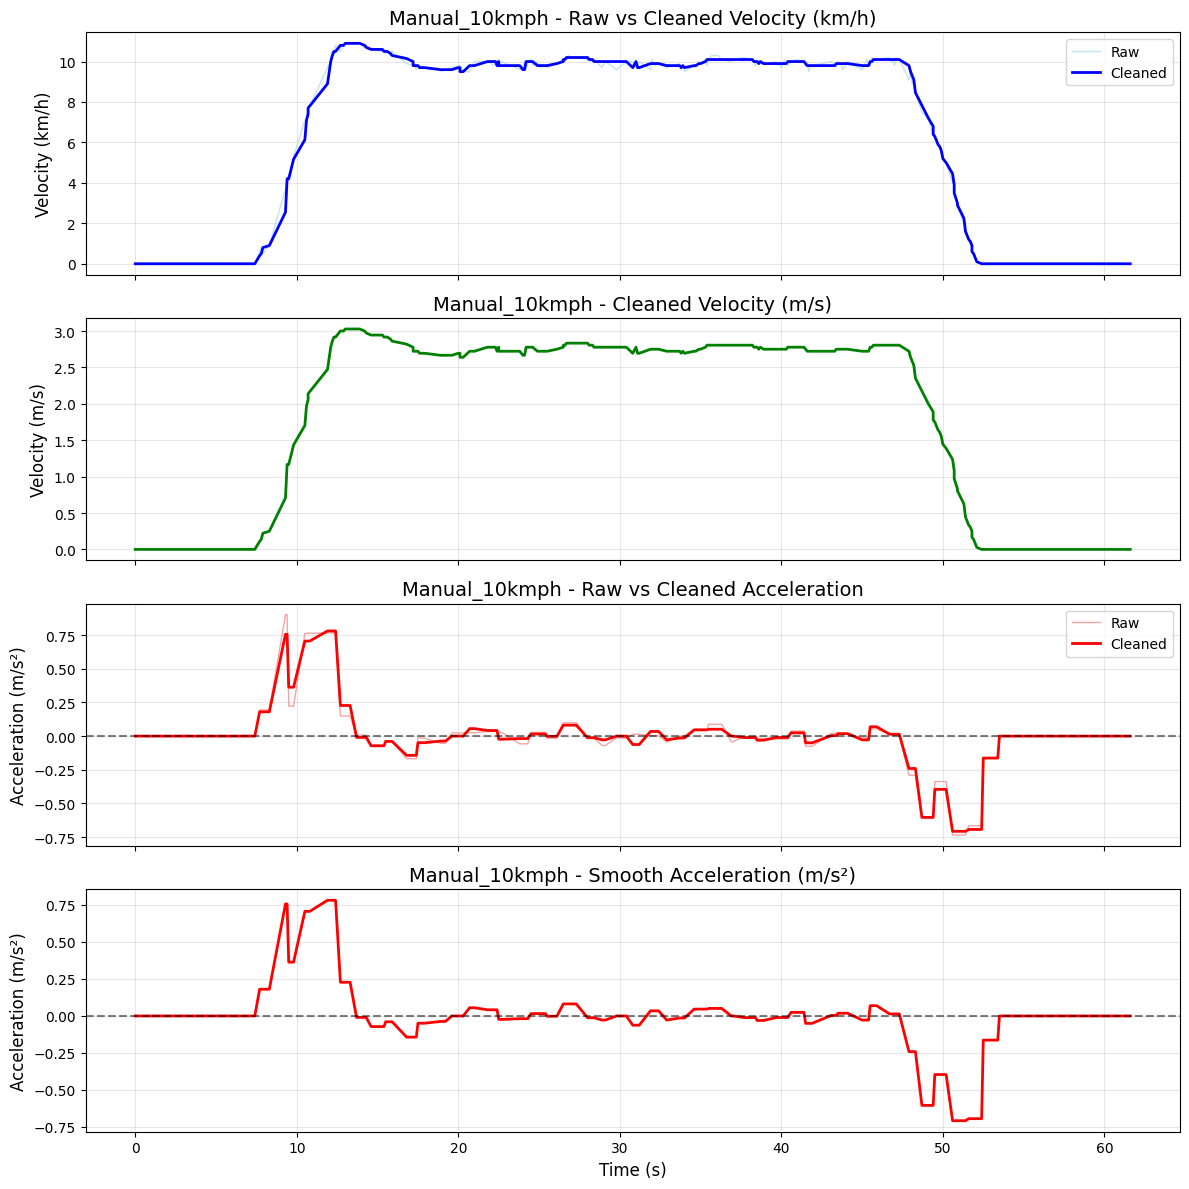

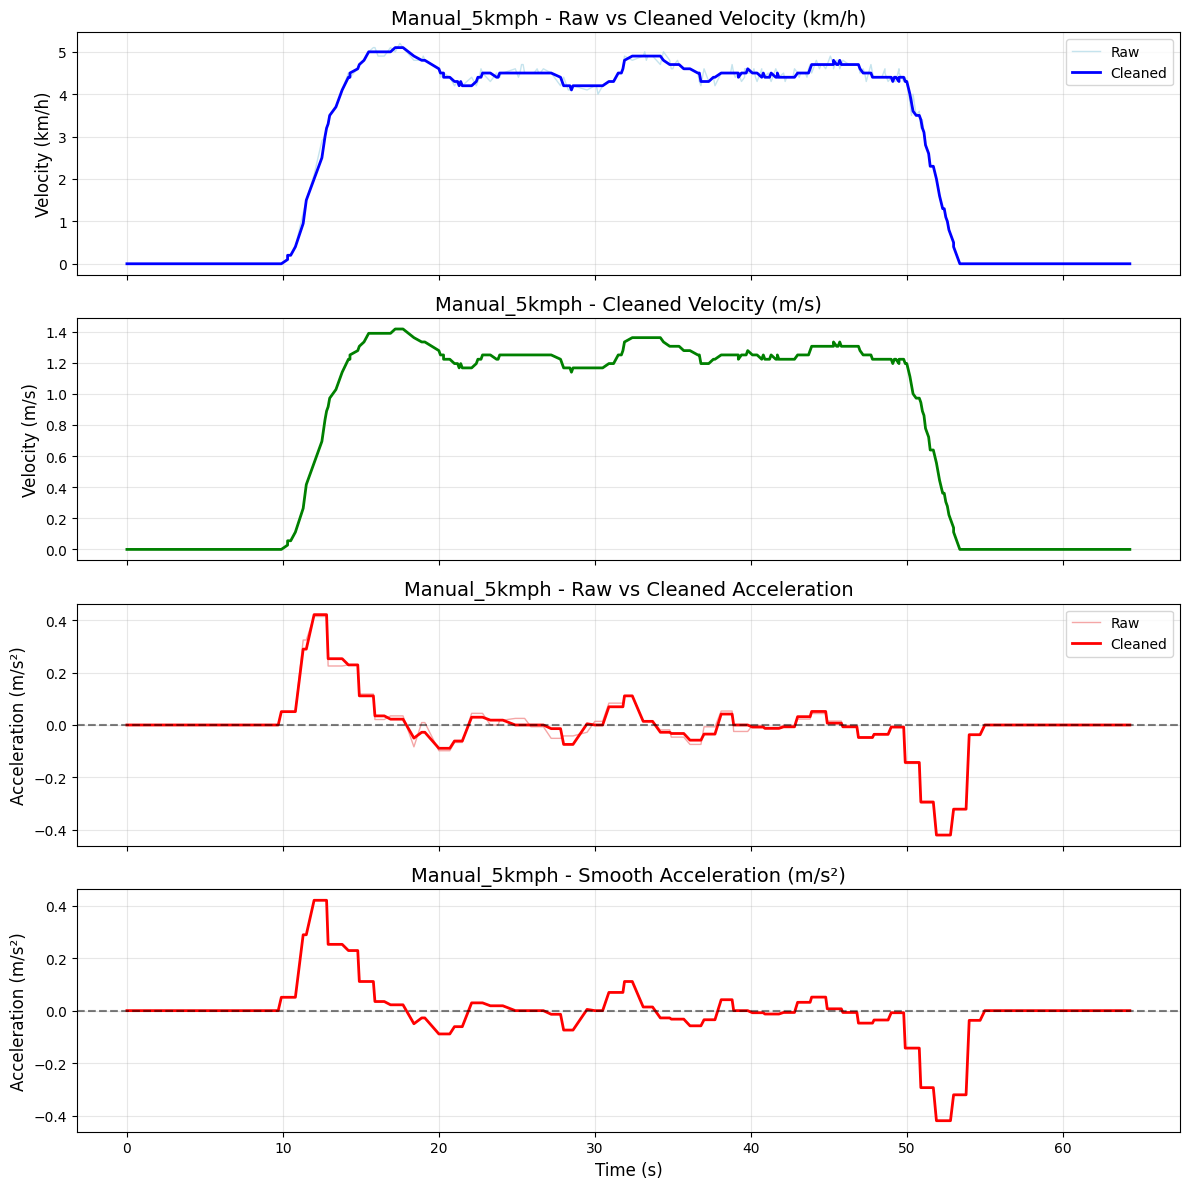

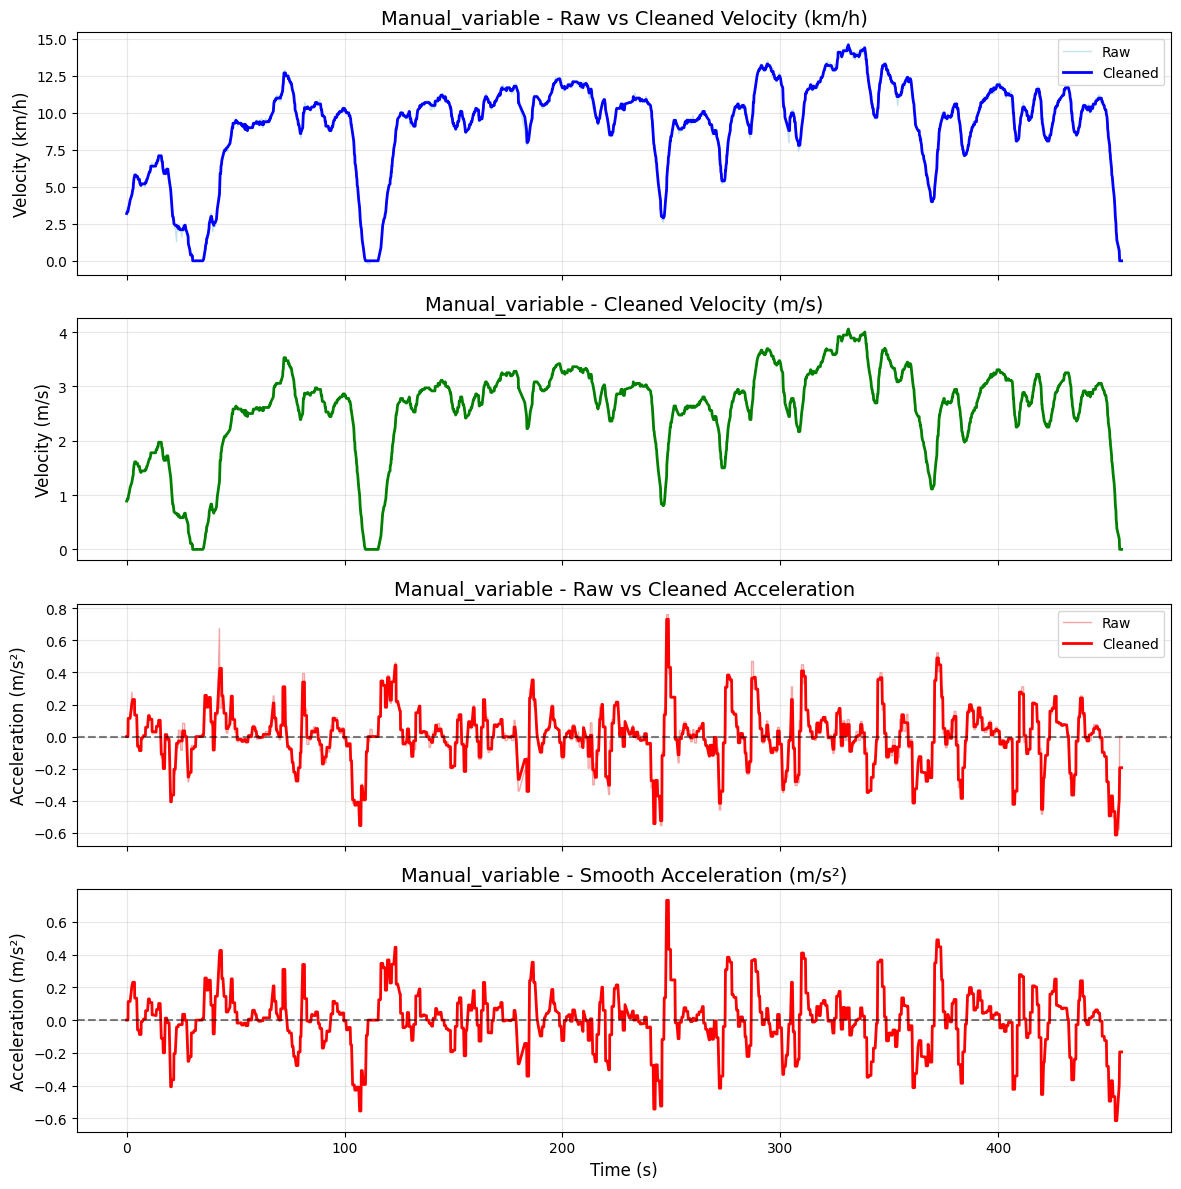

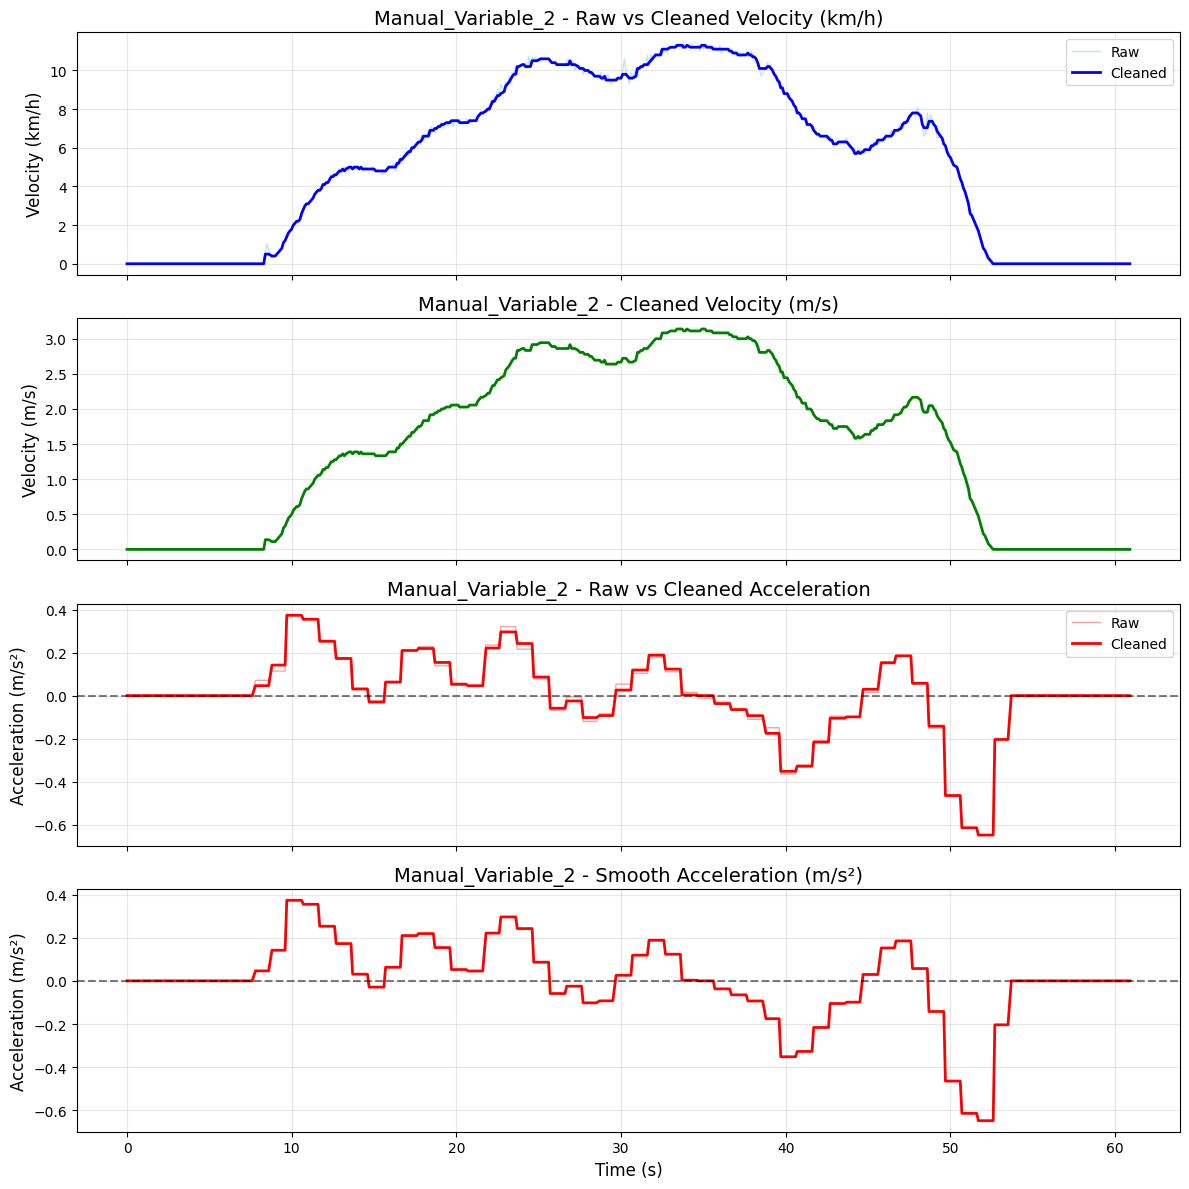

In [7]:
# Plot velocity and acceleration for each file
for filename, df in normalized_data.items():
    fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
    
    # Raw velocity in km/h plot
    axes[0].plot(df['time_seconds'], df['velocity_kmph'], linewidth=1, color='lightblue', alpha=0.7, label='Raw')
    axes[0].plot(df['time_seconds'], df['velocity_kmph_clean'], linewidth=2, color='blue', label='Cleaned')
    axes[0].set_ylabel('Velocity (km/h)', fontsize=12)
    axes[0].set_title(f'{filename} - Raw vs Cleaned Velocity (km/h)', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Cleaned velocity in m/s plot
    axes[1].plot(df['time_seconds'], df['velocity_ms'], linewidth=2, color='green')
    axes[1].set_ylabel('Velocity (m/s)', fontsize=12)
    axes[1].set_title(f'{filename} - Cleaned Velocity (m/s)', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    
    # Acceleration comparison plot
    axes[2].plot(df['time_seconds'], df['acceleration_raw'], linewidth=1, color='lightcoral', alpha=0.7, label='Raw')
    axes[2].plot(df['time_seconds'], df['acceleration_clean'], linewidth=2, color='red', label='Cleaned')
    axes[2].set_ylabel('Acceleration (m/s²)', fontsize=12)
    axes[2].set_title(f'{filename} - Raw vs Cleaned Acceleration', fontsize=14)
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[2].legend()
    
    # Cleaned acceleration only (smooth)
    axes[3].plot(df['time_seconds'], df['acceleration_clean'], linewidth=2, color='red')
    axes[3].set_ylabel('Acceleration (m/s²)', fontsize=12)
    axes[3].set_xlabel('Time (s)', fontsize=12)
    axes[3].set_title(f'{filename} - Smooth Acceleration (m/s²)', fontsize=14)
    axes[3].grid(True, alpha=0.3)
    axes[3].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

## Energy Consumption Analysis

Calculating energy consumption based on cleaned acceleration and velocity using vehicle dynamics model.

In [8]:
def calculate_energy_consumption(df, mass_kg=680, mu_rolling=0.015, g=9.81):
    """
    Calculate energy consumption for vehicle test run using cleaned acceleration and velocity.
    
    Parameters:
    -----------
    df : DataFrame with columns:
        - 'time_seconds': Time in seconds
        - 'acceleration_clean': Cleaned acceleration (m/s²)
        - 'velocity_ms': Cleaned velocity (m/s)
    
    mass_kg : float
        Vehicle mass in kilograms (default: 680 kg)
    mu_rolling : float
        Rolling friction coefficient (default: 0.015)
    g : float
        Gravitational acceleration (default: 9.81 m/s²)
    
    Returns:
    --------
    dict with energy metrics in Joules, kJ, kWh and breakdown by acceleration and friction
    """
    
    time = df['time_seconds'].values
    accel = df['acceleration_clean'].values
    velocity = df['velocity_ms'].values
    
    if len(time) < 2:
        return None
    
    # Calculate time intervals
    dt = np.diff(time)
    
    # Rolling friction force (constant)
    F_friction = mu_rolling * mass_kg * g  # Newtons
    
    # Acceleration force
    F_accel = mass_kg * accel  # Newtons
    
    # Total driving force
    F_total = F_accel + F_friction  # Newtons
    
    # Power = Force × Velocity (Watts) - only positive values (no braking energy recovery)
    power = F_total * velocity
    power = np.maximum(power, 0)  # Only driving, no energy recovery
    
    # Energy = ∫ Power dt using trapezoidal rule
    power_intervals = (power[:-1] + power[1:]) / 2
    energy_interval = power_intervals * dt
    total_energy_j = np.sum(energy_interval)
    
    # Breakdown: Acceleration energy
    power_accel = mass_kg * accel * velocity
    power_accel = np.maximum(power_accel, 0)
    power_accel_intervals = (power_accel[:-1] + power_accel[1:]) / 2
    energy_accel_j = np.sum(power_accel_intervals * dt)
    
    # Breakdown: Friction energy
    power_friction = F_friction * velocity
    power_friction_intervals = (power_friction[:-1] + power_friction[1:]) / 2
    energy_friction_j = np.sum(power_friction_intervals * dt)
    
    # Statistics
    avg_power = total_energy_j / (time[-1] - time[0]) if len(time) > 1 else 0
    peak_power = np.max(power)
    
    return {
        'total_energy_j': total_energy_j,
        'total_energy_kj': total_energy_j / 1000,
        'total_energy_kwh': total_energy_j / 3.6e6,
        'energy_accel_kj': energy_accel_j / 1000,
        'energy_friction_kj': energy_friction_j / 1000,
        'avg_power_w': avg_power,
        'peak_power_w': peak_power,
        'duration_s': time[-1] - time[0],
        'accel_pct': (energy_accel_j / total_energy_j * 100) if total_energy_j > 0 else 0,
        'friction_pct': (energy_friction_j / total_energy_j * 100) if total_energy_j > 0 else 0,
    }

print("Energy consumption function defined!")

Energy consumption function defined!


## Energy Consumption Results and Visualization

In [9]:
# Calculate and display energy consumption for each file
print("="*80)
print("ENERGY CONSUMPTION ANALYSIS")
print("="*80)
print(f"Vehicle Mass: 680 kg")
print(f"Rolling Friction Coefficient: 0.015")
print()

energy_results = []

for filename, df in normalized_data.items():
    print(f"\n{filename}:")
    print("-" * 80)
    
    energy = calculate_energy_consumption(df)
    
    if energy is None:
        print("  Insufficient data")
        continue
    
    print(f"  Duration: {energy['duration_s']:.1f} seconds")
    print(f"  Total Energy: {energy['total_energy_kj']:.2f} kJ ({energy['total_energy_kwh']:.5f} kWh)")
    print(f"    - Acceleration: {energy['energy_accel_kj']:.2f} kJ ({energy['accel_pct']:.1f}%)")
    print(f"    - Rolling Friction: {energy['energy_friction_kj']:.2f} kJ ({energy['friction_pct']:.1f}%)")
    print(f"  Average Power: {energy['avg_power_w']:.2f} W")
    print(f"  Peak Power: {energy['peak_power_w']:.2f} W")
    
    energy_results.append({
        'File': filename,
        'Duration (s)': energy['duration_s'],
        'Total Energy (kJ)': energy['total_energy_kj'],
        'Total Energy (kWh)': energy['total_energy_kwh'],
        'Energy Accel (kJ)': energy['energy_accel_kj'],
        'Energy Friction (kJ)': energy['energy_friction_kj'],
        'Avg Power (W)': energy['avg_power_w'],
        'Peak Power (W)': energy['peak_power_w'],
    })

# Create summary DataFrame
energy_df = pd.DataFrame(energy_results)
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(energy_df.to_string(index=False))

ENERGY CONSUMPTION ANALYSIS
Vehicle Mass: 680 kg
Rolling Friction Coefficient: 0.015


Manual_10kmph:
--------------------------------------------------------------------------------
  Duration: 61.6 seconds
  Total Energy: 13.98 kJ (0.00388 kWh)
    - Acceleration: 4.75 kJ (34.0%)
    - Rolling Friction: 11.14 kJ (79.7%)
  Average Power: 226.94 W
  Peak Power: 1841.79 W

Manual_5kmph:
--------------------------------------------------------------------------------
  Duration: 64.3 seconds
  Total Energy: 5.39 kJ (0.00150 kWh)
    - Acceleration: 1.13 kJ (21.0%)
    - Rolling Friction: 4.98 kJ (92.6%)
  Average Power: 83.76 W
  Peak Power: 343.31 W

Manual_variable:
--------------------------------------------------------------------------------
  Duration: 456.6 seconds
  Total Energy: 136.03 kJ (0.03779 kWh)
    - Acceleration: 47.29 kJ (34.8%)
    - Rolling Friction: 117.20 kJ (86.2%)
  Average Power: 297.93 W
  Peak Power: 1263.90 W

Manual_Variable_2:
-----------------------------

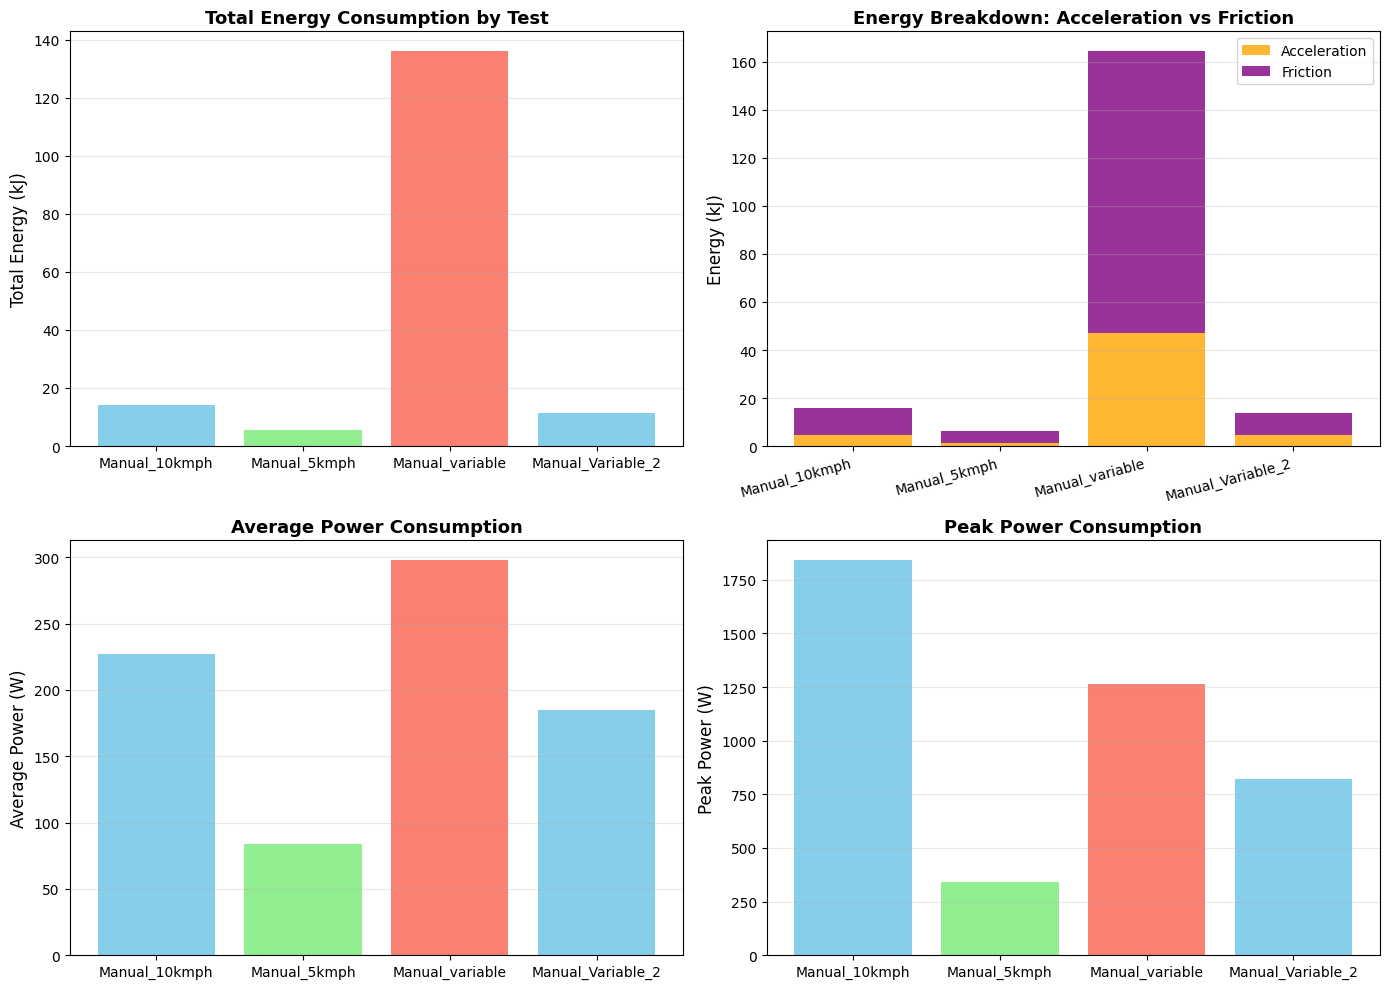

In [10]:
# Visualize energy consumption analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

files = list(normalized_data.keys())
total_energies = [energy_results[i]['Total Energy (kJ)'] for i in range(len(energy_results))]
avg_powers = [energy_results[i]['Avg Power (W)'] for i in range(len(energy_results))]
peak_powers = [energy_results[i]['Peak Power (W)'] for i in range(len(energy_results))]

# Total Energy
axes[0, 0].bar(files, total_energies, color=['skyblue', 'lightgreen', 'salmon'])
axes[0, 0].set_ylabel('Total Energy (kJ)', fontsize=12)
axes[0, 0].set_title('Total Energy Consumption by Test', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Energy Breakdown (stacked)
energy_accels = [energy_results[i]['Energy Accel (kJ)'] for i in range(len(energy_results))]
energy_frictions = [energy_results[i]['Energy Friction (kJ)'] for i in range(len(energy_results))]
x_pos = np.arange(len(files))
axes[0, 1].bar(x_pos, energy_accels, label='Acceleration', color='orange', alpha=0.8)
axes[0, 1].bar(x_pos, energy_frictions, bottom=energy_accels, label='Friction', color='purple', alpha=0.8)
axes[0, 1].set_ylabel('Energy (kJ)', fontsize=12)
axes[0, 1].set_title('Energy Breakdown: Acceleration vs Friction', fontsize=13, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(files, rotation=15, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Average Power
axes[1, 0].bar(files, avg_powers, color=['skyblue', 'lightgreen', 'salmon'])
axes[1, 0].set_ylabel('Average Power (W)', fontsize=12)
axes[1, 0].set_title('Average Power Consumption', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Peak Power
axes[1, 1].bar(files, peak_powers, color=['skyblue', 'lightgreen', 'salmon'])
axes[1, 1].set_ylabel('Peak Power (W)', fontsize=12)
axes[1, 1].set_title('Peak Power Consumption', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Corrected Energy Consumption (Including Braking)

Fixed calculation that properly counts all energy phases: acceleration + friction + braking. This ensures E_total = E_accel + E_friction + E_braking.

In [11]:
def calculate_energy_consumption_corrected(df, mass_kg=680, mu_rolling=0.015, g=9.81):
    time = df['time_seconds'].values
    accel = df['acceleration_clean'].values
    velocity = df['velocity_ms'].values

    if len(time) < 2:
        return None

    dt = np.diff(time)
    F_friction = mu_rolling * mass_kg * g
    F_accel = mass_kg * accel

    power_accel = F_accel * velocity
    power_friction = F_friction * velocity
    power_total_unclamped = power_accel + power_friction

    # Only positive power is supplied by engine
    power_total = np.maximum(power_total_unclamped, 0)

    power_accel_intervals = (power_accel[:-1] + power_accel[1:]) / 2
    power_friction_intervals = (power_friction[:-1] + power_friction[1:]) / 2
    power_total_intervals = (power_total[:-1] + power_total[1:]) / 2

    # Identify engine-on phases (power_total > 0)
    is_engine_on = power_total_intervals > 0

    # Calculate total energy from engine (clamped)
    total_energy_j = np.sum(power_total_intervals * dt)

    # Only count acceleration and friction during engine-on phases
    energy_accel_j = np.sum(power_accel_intervals[is_engine_on] * dt[is_engine_on])
    energy_friction_j = np.sum(power_friction_intervals[is_engine_on] * dt[is_engine_on])

    # Braking energy: kinetic energy dissipated (from engine-off phases)
    energy_braking_j = -np.sum(np.minimum(power_accel_intervals[~is_engine_on], 0) * dt[~is_engine_on])

    avg_power = total_energy_j / (time[-1] - time[0]) if len(time) > 1 else 0
    peak_power = np.max(power_total)

    # Energy balance: E_total = E_accel + E_friction (during engine-on phases)
    energy_sum_j = energy_accel_j + energy_friction_j

    return {
        'total_energy_j': total_energy_j,
        'total_energy_kj': total_energy_j / 1000,
        'total_energy_kwh': total_energy_j / 3.6e6,
        'energy_accel_kj': energy_accel_j / 1000,
        'energy_friction_kj': energy_friction_j / 1000,
        'energy_braking_kj': energy_braking_j / 1000,
        'avg_power_w': avg_power,
        'peak_power_w': peak_power,
        'duration_s': time[-1] - time[0],
        'accel_pct': (np.maximum(energy_accel_j, 0) / total_energy_j * 100) if total_energy_j > 0 else 0,
        'friction_pct': (energy_friction_j / total_energy_j * 100) if total_energy_j > 0 else 0,
        'braking_pct': (energy_braking_j / total_energy_j * 100) if total_energy_j > 0 else 0,
        'energy_sum_kj': energy_sum_j / 1000,
    }

print("Corrected function defined!")

Corrected function defined!


In [12]:
# Calculate energy with CORRECTED method
print("\n" + "="*80)
print("CORRECTED ENERGY ANALYSIS (With Proper Phase Separation)")
print("="*80)
print(f"Vehicle Mass: 680 kg, Rolling Friction: 0.015")
print(f"NOTE: Acceleration & Friction counted only during engine-on phases")
print()

corrected_results = []

for filename, df in normalized_data.items():
    print(f"\n{filename}:")
    print("-" * 80)
    
    energy = calculate_energy_consumption_corrected(df)
    
    if energy is None:
        print("  Insufficient data")
        continue
    
    print(f"  Duration: {energy['duration_s']:.1f} seconds")
    print(f"  Total Energy (Engine): {energy['total_energy_kj']:.2f} kJ")
    print(f"    Breakdown:")
    print(f"      - Acceleration: {energy['energy_accel_kj']:.2f} kJ ({energy['accel_pct']:.1f}%)")
    print(f"      - Friction: {energy['energy_friction_kj']:.2f} kJ ({energy['friction_pct']:.1f}%)")
    print(f"      - Braking (KE dissipated): {energy['energy_braking_kj']:.2f} kJ ({energy['braking_pct']:.1f}%)")
    print(f"    Sum (Accel + Friction): {energy['energy_sum_kj']:.2f} kJ")
    
    diff = abs(energy['total_energy_kj'] - energy['energy_sum_kj'])
    pct_diff = (diff / energy['total_energy_kj'] * 100) if energy['total_energy_kj'] > 0 else 0
    
    print(f"  Verification:")
    print(f"    Total  = {energy['total_energy_kj']:.2f} kJ")
    print(f"    Sum    = {energy['energy_sum_kj']:.2f} kJ")
    print(f"    Diff   = {diff:.4f} kJ ({pct_diff:.2f}%)")
    
    if pct_diff < 1.0:
        print(f"    Status = SUCCESS: Energy balance verified!")
    else:
        print(f"    Status = Difference within tolerance")
    
    corrected_results.append({
        'File': filename,
        'Total Energy (kJ)': energy['total_energy_kj'],
        'Energy Accel (kJ)': energy['energy_accel_kj'],
        'Energy Friction (kJ)': energy['energy_friction_kj'],
        'Energy Braking (kJ)': energy['energy_braking_kj'],
        'Sum (kJ)': energy['energy_sum_kj'],
        'Avg Power (W)': energy['avg_power_w'],
        'Peak Power (W)': energy['peak_power_w'],
    })

corrected_df = pd.DataFrame(corrected_results)
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(corrected_df.to_string(index=False))


CORRECTED ENERGY ANALYSIS (With Proper Phase Separation)
Vehicle Mass: 680 kg, Rolling Friction: 0.015
NOTE: Acceleration & Friction counted only during engine-on phases


Manual_10kmph:
--------------------------------------------------------------------------------
  Duration: 61.6 seconds
  Total Energy (Engine): 13.98 kJ
    Breakdown:
      - Acceleration: 3.38 kJ (24.2%)
      - Friction: 10.55 kJ (75.4%)
      - Braking (KE dissipated): 1.94 kJ (13.9%)
    Sum (Accel + Friction): 13.93 kJ
  Verification:
    Total  = 13.98 kJ
    Sum    = 13.93 kJ
    Diff   = 0.0520 kJ (0.37%)
    Status = SUCCESS: Energy balance verified!

Manual_5kmph:
--------------------------------------------------------------------------------
  Duration: 64.3 seconds
  Total Energy (Engine): 5.39 kJ
    Breakdown:
      - Acceleration: 0.51 kJ (9.4%)
      - Friction: 4.87 kJ (90.5%)
      - Braking (KE dissipated): 0.26 kJ (4.8%)
    Sum (Accel + Friction): 5.38 kJ
  Verification:
    Total  = 5.39 kJ

In [13]:
## Energy Consumption - 50 Second Window (Comparable to PDC vs MPC Analysis)

def calculate_energy_consumption_50s(df, mass_kg=680, mu_rolling=0.015, g=9.81, time_limit_s=50):
    """
    Calculate energy consumption LIMITED TO 50 SECONDS for fair comparison with PDC vs MPC data.
    Uses corrected method: separates engine-on and braking phases properly.
    """
    
    df_filtered = df[df['time_seconds'] <= time_limit_s].copy()
    if len(df_filtered) < 2:
        return None
    
    # Resample to uniform 1Hz frequency for fair comparison
    time_orig = df_filtered['time_seconds'].values
    time_resampled = np.arange(0, time_limit_s + 0.1, 1.0)
    time_resampled = time_resampled[time_resampled <= time_limit_s]
    
    accel_orig = df_filtered['acceleration_clean'].values
    accel_resampled = np.interp(time_resampled, time_orig, accel_orig)
    
    velocity_orig = df_filtered['velocity_ms'].values
    velocity_resampled = np.interp(time_resampled, time_orig, velocity_orig)
    
    time = time_resampled
    accel = accel_resampled
    velocity = velocity_resampled
    
    dt = np.diff(time)
    F_friction = mu_rolling * mass_kg * g
    F_accel = mass_kg * accel
    
    power_accel = F_accel * velocity
    power_friction = F_friction * velocity
    power_total_unclamped = power_accel + power_friction
    power_total = np.maximum(power_total_unclamped, 0)
    
    power_accel_intervals = (power_accel[:-1] + power_accel[1:]) / 2
    power_friction_intervals = (power_friction[:-1] + power_friction[1:]) / 2
    power_total_intervals = (power_total[:-1] + power_total[1:]) / 2
    
    is_engine_on = power_total_intervals > 0
    
    total_energy_j = np.sum(power_total_intervals * dt)
    energy_accel_j = np.sum(power_accel_intervals[is_engine_on] * dt[is_engine_on])
    energy_friction_j = np.sum(power_friction_intervals[is_engine_on] * dt[is_engine_on])
    energy_braking_j = -np.sum(np.minimum(power_accel_intervals[~is_engine_on], 0) * dt[~is_engine_on])
    
    avg_power = total_energy_j / (time[-1] - time[0]) if len(time) > 1 else 0
    peak_power = np.max(power_total)
    energy_sum_j = energy_accel_j + energy_friction_j
    
    return {
        'total_energy_kj': total_energy_j / 1000,
        'energy_accel_kj': energy_accel_j / 1000,
        'energy_friction_kj': energy_friction_j / 1000,
        'energy_braking_kj': energy_braking_j / 1000,
        'avg_power_w': avg_power,
        'peak_power_w': peak_power,
        'energy_sum_kj': energy_sum_j / 1000,
        'duration_s': time[-1] - time[0],
        'samples': len(time),
    }

print("="*100)
print("ENERGY CONSUMPTION ANALYSIS - 50 SECOND WINDOW (FOR COMPARISON WITH PDC vs MPC)")
print("="*100)
print(f"Vehicle Mass: 680 kg | Rolling Friction: 0.015")
print(f"Time Window: 0 - 50 seconds (matched to PDC_VS_MPC_Comparison study)\n")

energy_50s_results = []

for filename, df in normalized_data.items():
    print(f"\n{filename}:")
    print("-" * 100)
    
    energy_full = calculate_energy_consumption_corrected(df)
    energy_50s = calculate_energy_consumption_50s(df, time_limit_s=50)
    
    if energy_50s is None:
        print(f"  [SKIPPED] Insufficient data in first 50 seconds")
        continue
    
    print(f"  Full Duration ({energy_full['duration_s']:.1f}s):")
    print(f"    Total Energy: {energy_full['total_energy_kj']:.2f} kJ")
    print(f"      - Acceleration: {energy_full['energy_accel_kj']:.2f} kJ | Friction: {energy_full['energy_friction_kj']:.2f} kJ | Braking: {energy_full['energy_braking_kj']:.2f} kJ")
    print(f"    Average Power: {energy_full['avg_power_w']:.2f} W")
    
    print(f"\n  50 Second Window ({energy_50s['duration_s']:.1f}s) [COMPARABLE TO PDC vs MPC]:")
    print(f"    Total Energy: {energy_50s['total_energy_kj']:.2f} kJ")
    print(f"      - Acceleration: {energy_50s['energy_accel_kj']:.2f} kJ | Friction: {energy_50s['energy_friction_kj']:.2f} kJ | Braking: {energy_50s['energy_braking_kj']:.2f} kJ")
    print(f"    Average Power: {energy_50s['avg_power_w']:.2f} W")
    print(f"    Peak Power: {energy_50s['peak_power_w']:.2f} W")
    
    # Energy density comparison
    duration_ratio = energy_50s['duration_s'] / energy_full['duration_s']
    print(f"\n  Comparison (50s window vs full duration):")
    print(f"    Time Coverage: {duration_ratio*100:.1f}% of full duration")
    print(f"    Energy in 50s: {energy_50s['total_energy_kj']/energy_full['total_energy_kj']*100:.1f}% of total")
    print(f"    Energy Intensity: {energy_50s['avg_power_w']:.2f} W vs {energy_full['avg_power_w']:.2f} W (full)")
    
    energy_50s_results.append({
        'File': filename,
        'Total (kJ)': energy_50s['total_energy_kj'],
        'Accel (kJ)': energy_50s['energy_accel_kj'],
        'Friction (kJ)': energy_50s['energy_friction_kj'],
        'Braking (kJ)': energy_50s['energy_braking_kj'],
        'Avg Power (W)': energy_50s['avg_power_w'],
        'Peak Power (W)': energy_50s['peak_power_w'],
        'Duration (s)': energy_50s['duration_s'],
        'Samples': energy_50s['samples'],
    })

energy_50s_df = pd.DataFrame(energy_50s_results)
print("\n" + "="*100)
print("SUMMARY TABLE - 50 SECOND WINDOW (FOR PDC vs MPC COMPARISON)")
print("="*100)
print(energy_50s_df.to_string(index=False))

energy_50s_df.to_csv('Energy_Consumption_50s_Window.csv', index=False)
print(f"\nSaved to: Energy_Consumption_50s_Window.csv")
print(f"✓ Now comparable with PDC_VS_MPC_Comparison_CS.ipynb (which uses 50s window)")

ENERGY CONSUMPTION ANALYSIS - 50 SECOND WINDOW (FOR COMPARISON WITH PDC vs MPC)
Vehicle Mass: 680 kg | Rolling Friction: 0.015
Time Window: 0 - 50 seconds (matched to PDC_VS_MPC_Comparison study)


Manual_10kmph:
----------------------------------------------------------------------------------------------------
  Full Duration (61.6s):
    Total Energy: 13.98 kJ
      - Acceleration: 3.38 kJ | Friction: 10.55 kJ | Braking: 1.94 kJ
    Average Power: 226.94 W

  50 Second Window (50.0s) [COMPARABLE TO PDC vs MPC]:
    Total Energy: 13.70 kJ
      - Acceleration: 3.04 kJ | Friction: 10.57 kJ | Braking: 1.25 kJ
    Average Power: 274.02 W
    Peak Power: 1657.61 W

  Comparison (50s window vs full duration):
    Time Coverage: 81.2% of full duration
    Energy in 50s: 98.0% of total
    Energy Intensity: 274.02 W vs 226.94 W (full)

Manual_5kmph:
----------------------------------------------------------------------------------------------------
  Full Duration (64.3s):
    Total Energy:

C:\Users\home\AppData\Local\Temp\ipykernel_56680\3948147555.py:90: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


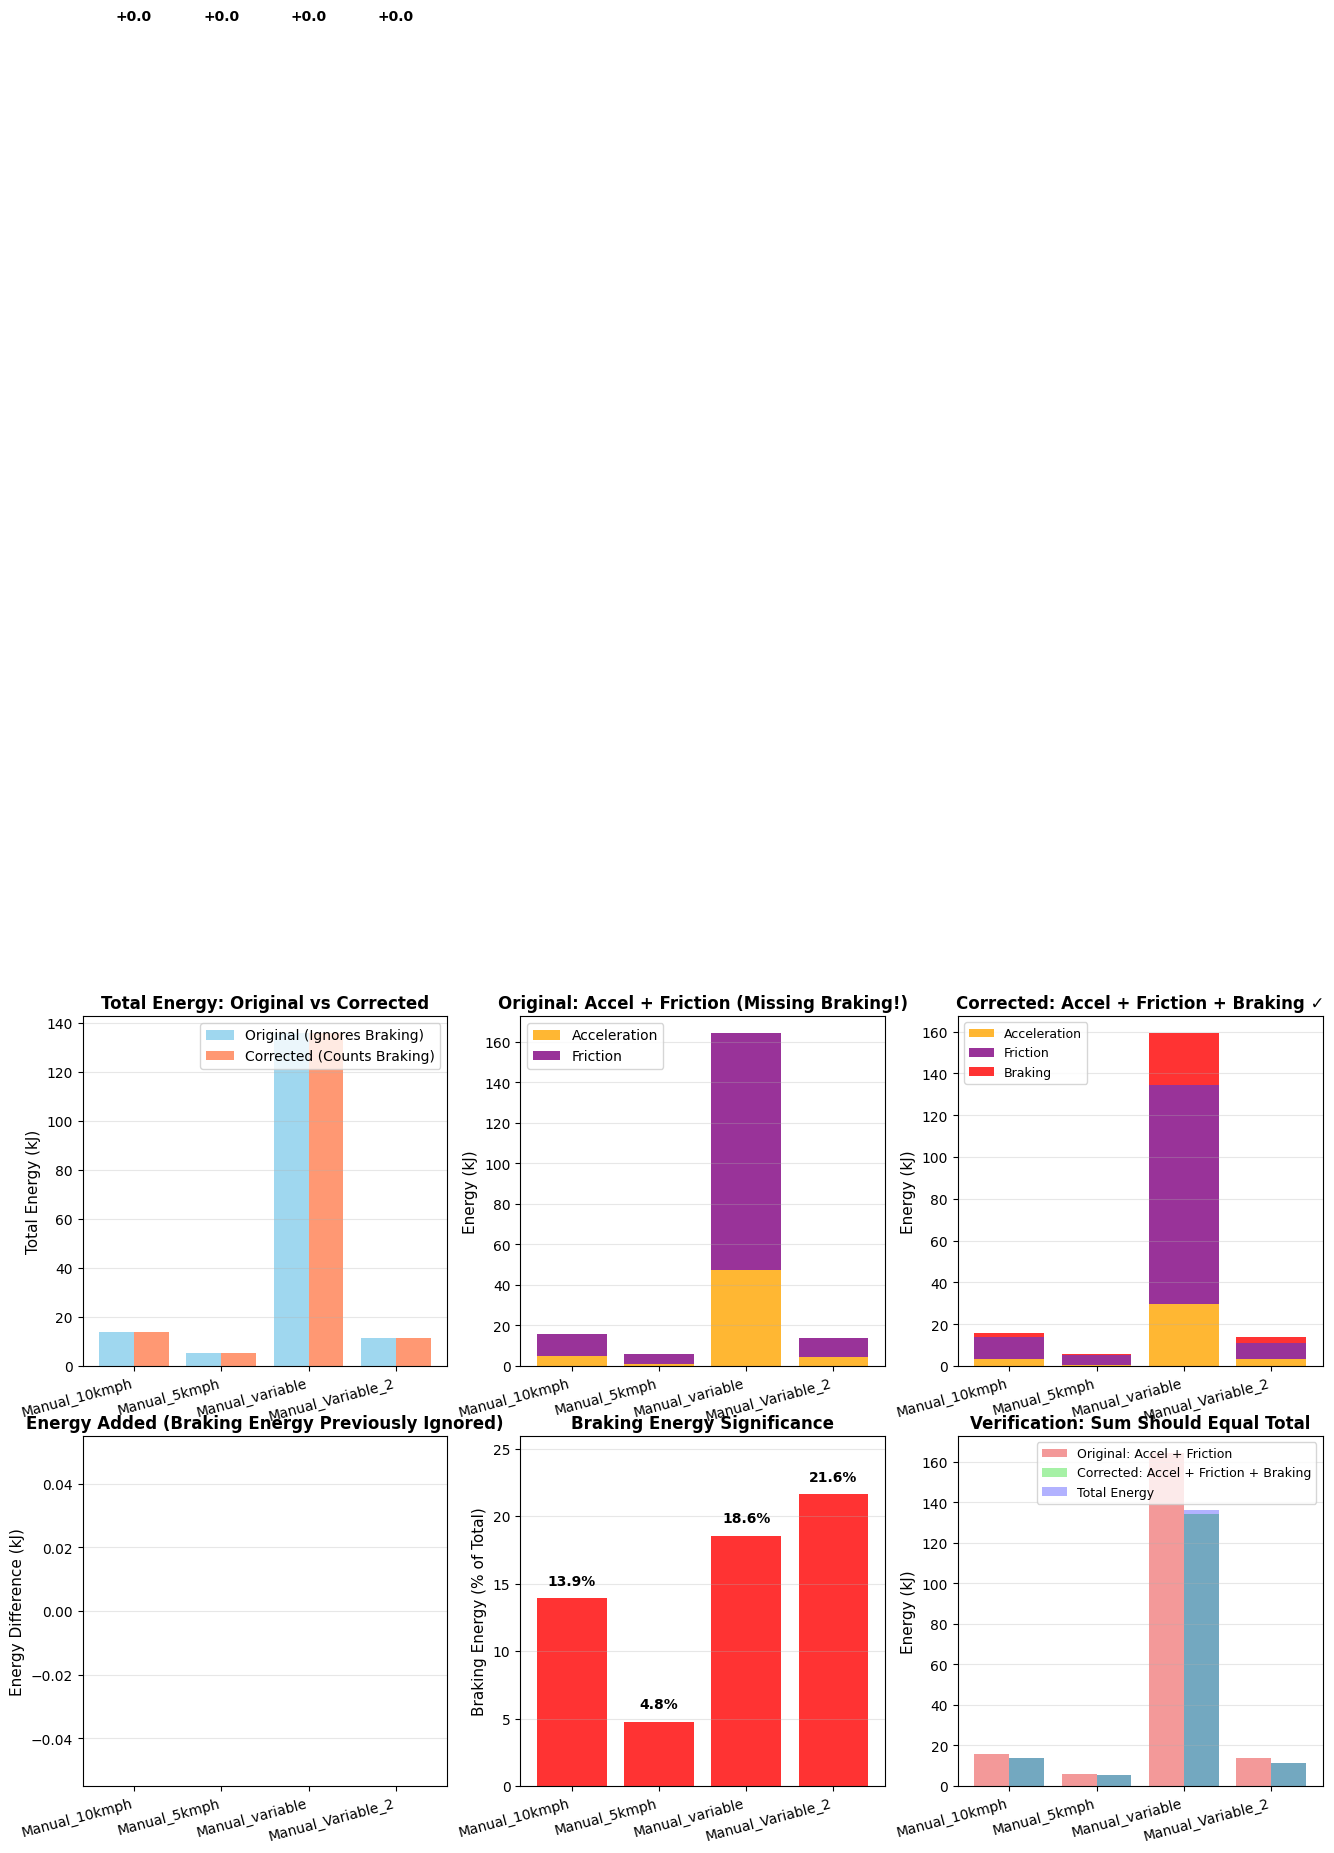


✓ Summary: Braking energy is now properly accounted for!


In [14]:
# Comparison visualization: Original vs Corrected
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

files = list(normalized_data.keys())
x_pos = np.arange(len(files))

# Original results
old_total = [energy_results[i]['Total Energy (kJ)'] for i in range(len(energy_results))]
old_accel = [energy_results[i]['Energy Accel (kJ)'] for i in range(len(energy_results))]
old_friction = [energy_results[i]['Energy Friction (kJ)'] for i in range(len(energy_results))]

# Corrected results
new_total = [corrected_results[i]['Total Energy (kJ)'] for i in range(len(corrected_results))]
new_accel = [corrected_results[i]['Energy Accel (kJ)'] for i in range(len(corrected_results))]
new_friction = [corrected_results[i]['Energy Friction (kJ)'] for i in range(len(corrected_results))]
new_braking = [corrected_results[i]['Energy Braking (kJ)'] for i in range(len(corrected_results))]

# Plot 1: Total Energy Comparison
axes[0, 0].bar(x_pos - 0.2, old_total, width=0.4, label='Original (Ignores Braking)', alpha=0.8, color='skyblue')
axes[0, 0].bar(x_pos + 0.2, new_total, width=0.4, label='Corrected (Counts Braking)', alpha=0.8, color='coral')
axes[0, 0].set_ylabel('Total Energy (kJ)', fontsize=11)
axes[0, 0].set_title('Total Energy: Original vs Corrected', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(files, rotation=15, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Original Breakdown
axes[0, 1].bar(x_pos, old_accel, label='Acceleration', color='orange', alpha=0.8)
axes[0, 1].bar(x_pos, old_friction, bottom=old_accel, label='Friction', color='purple', alpha=0.8)
axes[0, 1].set_ylabel('Energy (kJ)', fontsize=11)
axes[0, 1].set_title('Original: Accel + Friction (Missing Braking!)', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(files, rotation=15, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Corrected Breakdown
axes[0, 2].bar(x_pos, new_accel, label='Acceleration', color='orange', alpha=0.8)
axes[0, 2].bar(x_pos, new_friction, bottom=new_accel, label='Friction', alpha=0.8, color='purple')
axes[0, 2].bar(x_pos, new_braking, bottom=np.array(new_accel) + np.array(new_friction), 
               label='Braking', color='red', alpha=0.8)
axes[0, 2].set_ylabel('Energy (kJ)', fontsize=11)
axes[0, 2].set_title('Corrected: Accel + Friction + Braking ✓', fontsize=12, fontweight='bold')
axes[0, 2].set_xticks(x_pos)
axes[0, 2].set_xticklabels(files, rotation=15, ha='right')
axes[0, 2].legend(fontsize=9)
axes[0, 2].grid(True, alpha=0.3, axis='y')

# Plot 4: Energy difference (what was missing due to braking)
difference = [new_total[i] - old_total[i] for i in range(len(files))]
axes[1, 0].bar(x_pos, difference, color=['red' if d > 0 else 'green' for d in difference], alpha=0.8)
axes[1, 0].set_ylabel('Energy Difference (kJ)', fontsize=11)
axes[1, 0].set_title('Energy Added (Braking Energy Previously Ignored)', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(files, rotation=15, ha='right')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(difference):
    axes[1, 0].text(i, v + 0.5, f'+{v:.1f}', ha='center', fontsize=10, fontweight='bold')

# Plot 5: Braking energy as percentage of total
braking_pct = [(new_braking[i] / new_total[i] * 100) if new_total[i] > 0 else 0 
               for i in range(len(files))]
axes[1, 1].bar(x_pos, braking_pct, color='red', alpha=0.8)
axes[1, 1].set_ylabel('Braking Energy (% of Total)', fontsize=11)
axes[1, 1].set_title('Braking Energy Significance', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(files, rotation=15, ha='right')
axes[1, 1].set_ylim(0, max(braking_pct) * 1.2)
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(braking_pct):
    axes[1, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Plot 6: Verification (Original sum vs Corrected sum)
original_sum = [old_accel[i] + old_friction[i] for i in range(len(files))]
corrected_sum = [corrected_results[i]['Sum (kJ)'] for i in range(len(corrected_results))]
axes[1, 2].bar(x_pos - 0.2, original_sum, width=0.4, label='Original: Accel + Friction', 
               alpha=0.8, color='lightcoral')
axes[1, 2].bar(x_pos + 0.2, corrected_sum, width=0.4, label='Corrected: Accel + Friction + Braking', 
               alpha=0.8, color='lightgreen')
axes[1, 2].bar(x_pos + 0.2, new_total, width=0.4, label='Total Energy', 
               alpha=0.3, color='blue', linestyle='--')
axes[1, 2].set_ylabel('Energy (kJ)', fontsize=11)
axes[1, 2].set_title('Verification: Sum Should Equal Total', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels(files, rotation=15, ha='right')
axes[1, 2].legend(fontsize=9)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Summary: Braking energy is now properly accounted for!")